In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('Customer-Churn-Dataset.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df["TotalCharges"] = df["TotalCharges"].replace(" ","0")
df["TotalCharges"] = df["TotalCharges"].astype("float")

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
df.isnull().sum().sum()

np.int64(0)

In [10]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [11]:
df["customerID"].duplicated().sum()

np.int64(0)

In [12]:

df['SeniorCitizen'] = df['SeniorCitizen'].replace({1: 'yes', 0: 'no'})

In [13]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,no,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,no,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,no,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,no,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,no,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


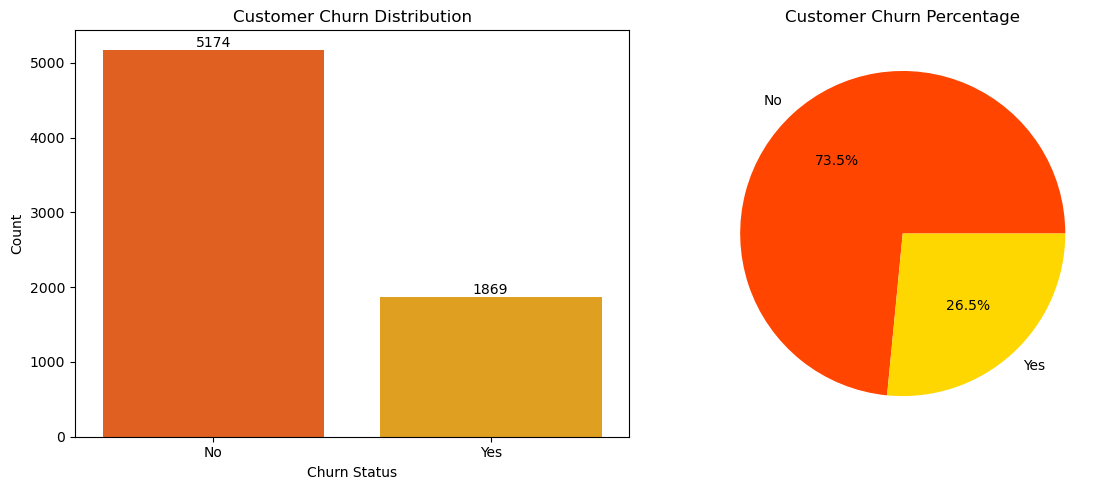

In [14]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
ax = sns.countplot(x='Churn', data=df, palette='autumn', hue='Churn', legend=False)
plt.title('Customer Churn Distribution')
plt.xlabel('Churn Status')
plt.ylabel('Count')
for container in ax.containers:
    ax.bar_label(container)

plt.subplot(1,2,2)
churn_counts = df['Churn'].value_counts()
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', colors=['orangered', 'gold'])
plt.title('Customer Churn Percentage')
plt.tight_layout()
plt.savefig("churn_distribution.png",dpi=300)
plt.show()

The distribution reveals a customer churn rate of 26.54%. We will now transition to an investigation into the underlying causes of this attrition.

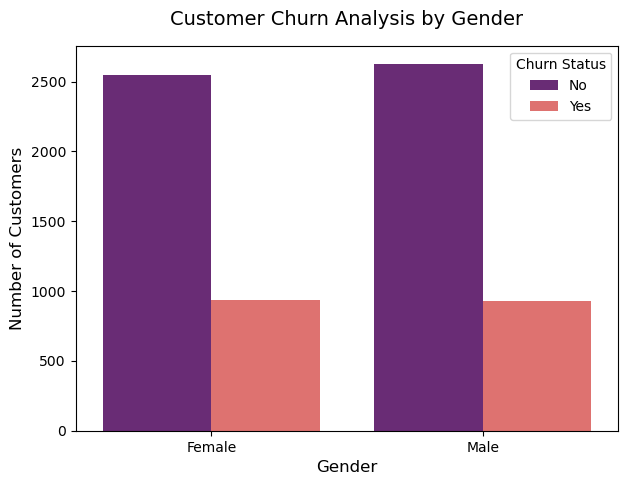

In [15]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="gender", hue="Churn", palette="magma")
plt.title("Customer Churn Analysis by Gender", fontsize=14, pad=15)
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)
plt.legend(title="Churn Status", loc="upper right")

plt.show()

Churn rates are nearly identical between male and female customers, showing gender has no significant effect on customer retention

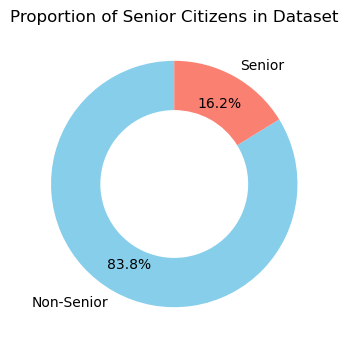

In [16]:
df["SeniorCitizen"].value_counts().plot.pie(
    autopct="%.1f%%", 
    startangle=90, 
    colors=["skyblue", "salmon"], 
    labels=["Non-Senior", "Senior"], 
    wedgeprops={"width": 0.4},
    pctdistance=0.75,
    figsize=(4, 4)
)
plt.ylabel("")
plt.title("Proportion of Senior Citizens in Dataset")
plt.show()

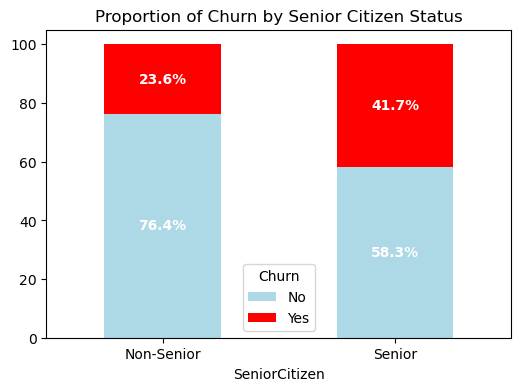

In [24]:
ax = (pd.crosstab(df["SeniorCitizen"], df["Churn"], normalize="index") * 100).plot(
    kind="bar", stacked=True, color=["lightblue", "red"], figsize=(6, 4)
)

for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%", label_type="center", color="white", weight="bold")

plt.xticks([0, 1], ["Non-Senior", "Senior"], rotation=0)
plt.title("Proportion of Churn by Senior Citizen Status")
plt.savefig("senior_citizen_vs_churn.png",dpi=300)
plt.show()

The data reveals a clear behavioral disparity between age groups. Senior citizens churn at a disproportionately higher rate (41.7%) than non-seniors (23.6%), indicating that senior status is a strong predictor of customer attrition.

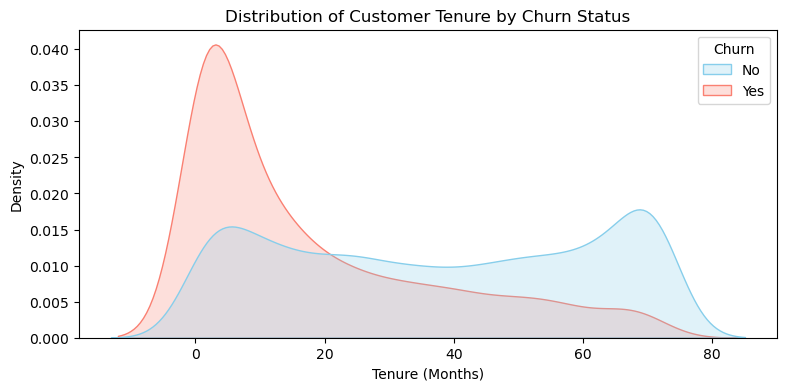

In [18]:
plt.figure(figsize=(9, 4))
sns.kdeplot(data=df, x="tenure", hue="Churn", fill=True, common_norm=False, palette=["skyblue", "salmon"])
plt.title("Distribution of Customer Tenure by Churn Status")
plt.xlabel("Tenure (Months)")
plt.ylabel("Density")
plt.savefig("tenure_vs_churn.png",dpi=300)
plt.show()

Most churn happens instantly within the first few months of joining. Customers who stay past the first year become highly stable, with loyalty peaking at the 72-month mark.

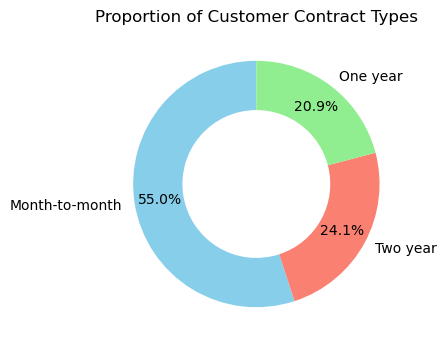

In [22]:
df["Contract"].value_counts().plot.pie(
    autopct="%.1f%%",
    startangle=90,
    colors=["skyblue", "salmon", "lightgreen"],
    wedgeprops={"width": 0.4},
    pctdistance=0.79,
    figsize=(4, 4)
)
plt.ylabel("")
plt.title("Proportion of Customer Contract Types")
plt.savefig("contract_type_vs_churn.png",dpi=300)
plt.show()

Month-to-month contracts drive the highest churn risk, whereas long-term commitments significantly improve customer retention.

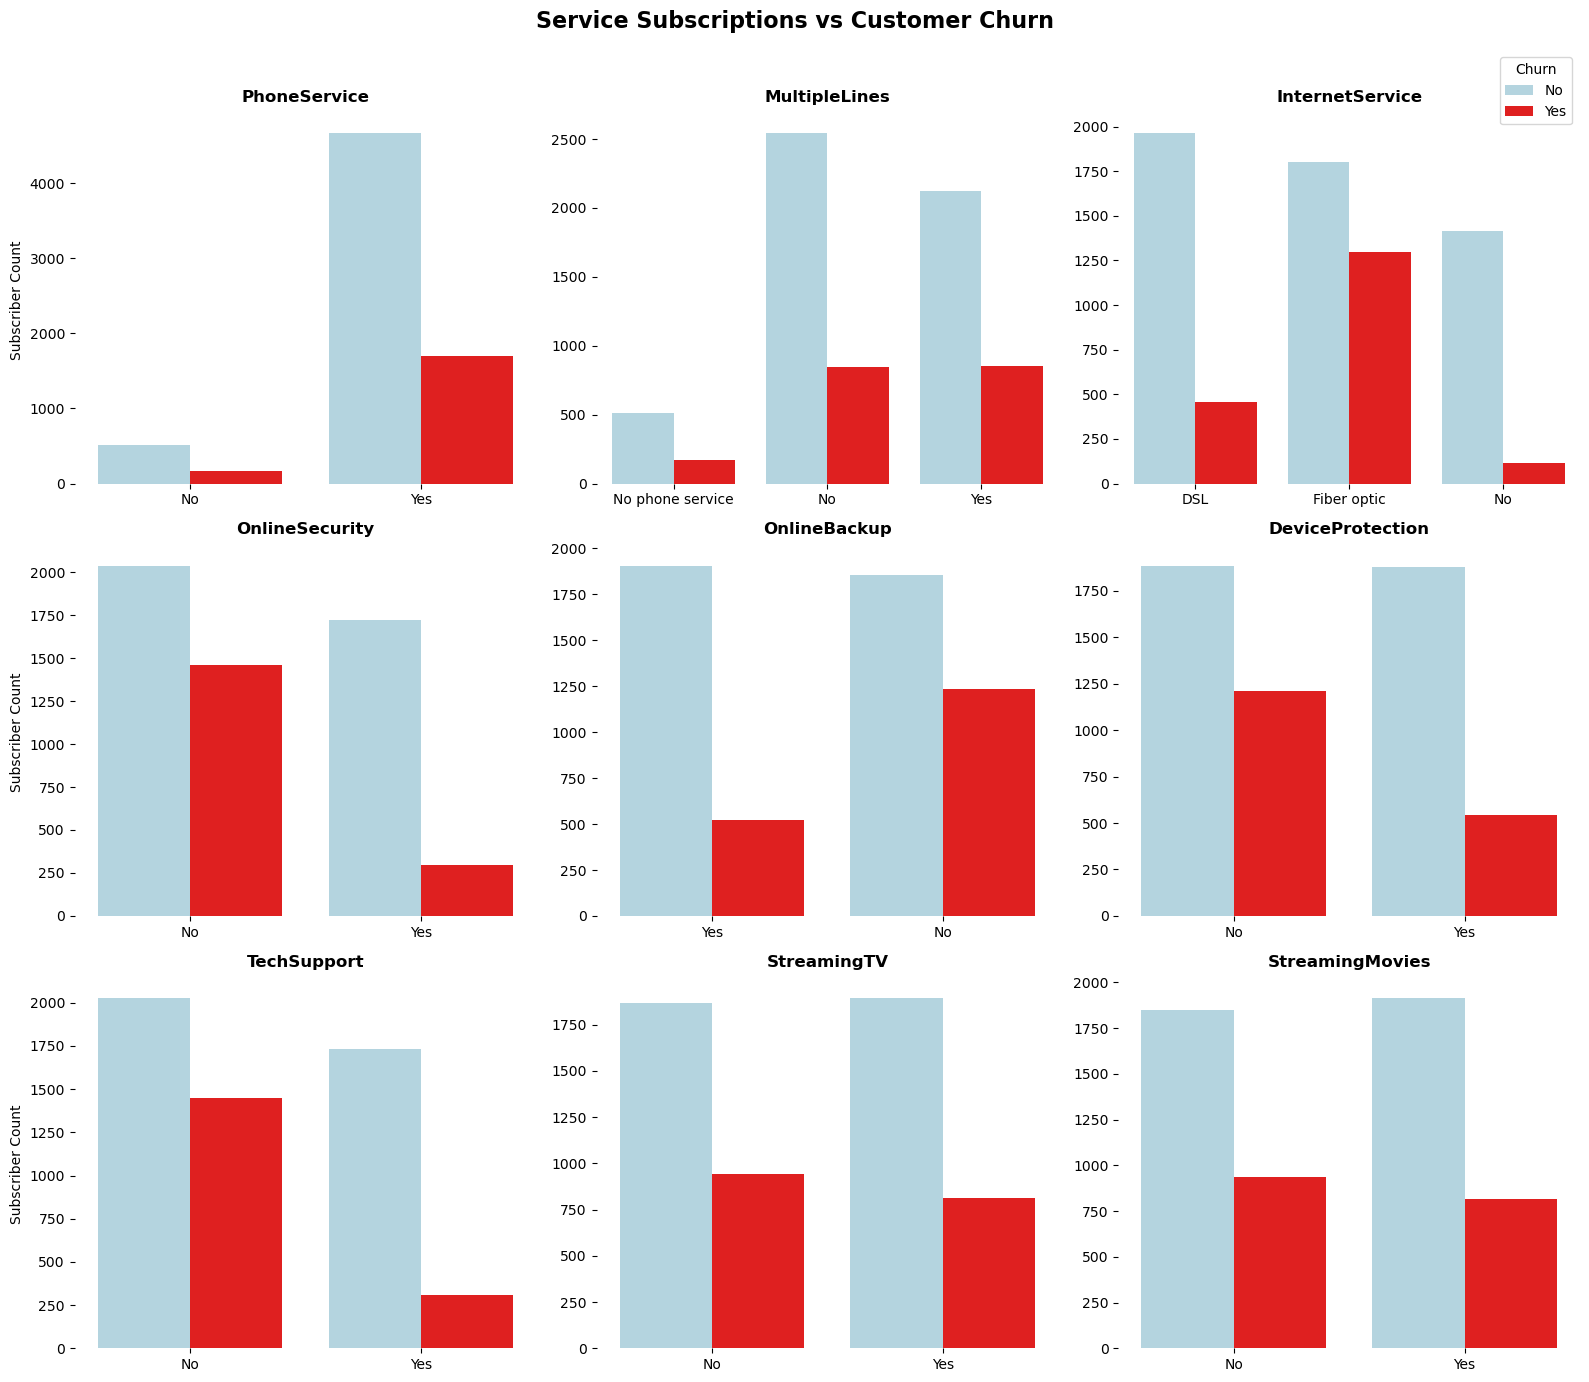

In [25]:
columns = [
    'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

n_cols = 3
n_rows = (len(columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4.5))
axes = axes.flatten()

churn_colors = {'No': 'lightblue', 'Yes': 'red'}

for i, col in enumerate(columns):   
    clean_df = df[df[col] != 'No internet service']

    sns.countplot(
        x=col,
        data=clean_df,
        hue='Churn',
        ax=axes[i],
        palette=churn_colors,
        hue_order=['No', 'Yes']
    )

    axes[i].set_title(f"{col}", fontsize=12, fontweight='bold', pad=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Subscriber Count' if i % n_cols == 0 else '')
    axes[i].get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Churn', loc='upper right', bbox_to_anchor=(0.99, 0.99))

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Service Subscriptions vs Customer Churn', fontsize=16, fontweight='bold', y=1.02)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig("service_subscription_vs_churn",dpi=300)
plt.show()

TechSupport: Customers without Tech Support show a massive surge in churn, while those with the service are highly loyal.
StreamingTV and StreamingMovies: Entertainment streaming features show similar, stable churn rates whether the service is active or not.

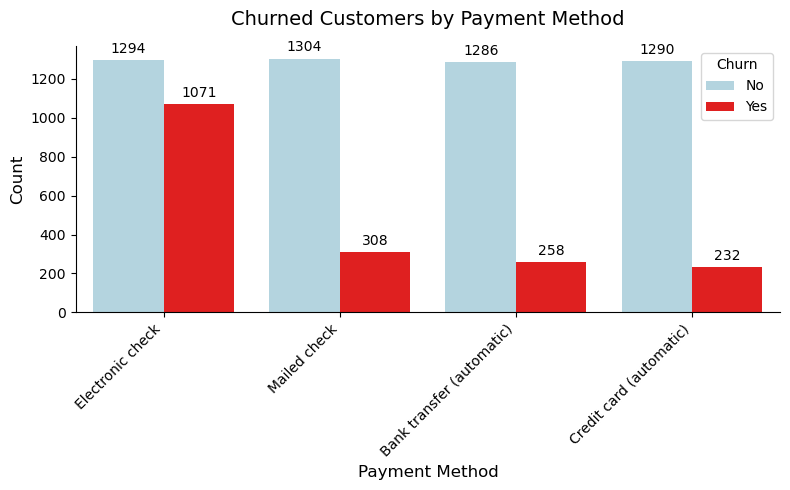

In [23]:

plt.figure(figsize=(8, 5))

custom_palette = {"Yes": "red", "No": "lightblue"}

ax = sns.countplot(
    x="PaymentMethod", 
    data=df, 
    hue="Churn", 
    palette=custom_palette
)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title("Churned Customers by Payment Method", fontsize=14, pad=15)
plt.xlabel("Payment Method", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45, ha="right")

sns.despine()
plt.tight_layout()
plt.savefig("payment_method_vs_churn.png",dpi=300)
plt.show()

Electronic Check users are the highest risk group, accounting for nearly half of all lost customers. In contrast, Credit Card and Bank Transfer options form the most loyal segments, as automatic payments significantly boost retention. Mailed Checks show low overall churn volume and a highly stable customer profile.